# 4장 실습 — LIF 뉴런 모델 깊이 이해하기

**Spiking Neural Networks 쿡북 with Python** · 4장 실습 노트북

누설 적분-발화(LIF) 뉴런의 동역학을 직접 시뮬레이션한다. RC 충전부터 `snn.Lapicque`·`snn.Leaky`, 그리고 두 가지 리셋 방식까지 비교한다.

### 학습 목표
- RC 누설 적분식으로 막전위 충전을 시뮬레이션한다.
- `snn.Lapicque`로 계단 입력 반응을 관찰한다.
- 감쇠율 `beta`와 리셋 방식이 발화에 주는 영향을 비교한다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다.

## 1. 설치와 임포트

In [1]:
import torch
import snntorch as snn
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0)

## 2. RC 누설 적분식으로 막전위 충전 보기

입력 전류가 일정할 때 막전위가 어떻게 정상상태로 차오르는지 직접 식으로 계산한다. `tau = R*C`이고, 매 스텝 `U ← U + (Δt/τ)(−U + I·R)`로 갱신한다(스파이크 없는 순수 누설 적분).

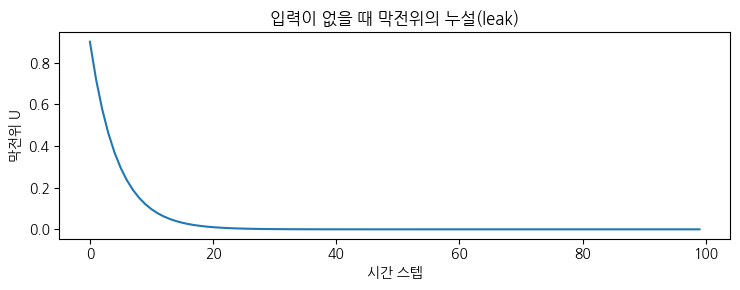

In [2]:
def leaky_integrate(U, I=0.0, time_step=1e-3, R=5e7, C=1e-10):
    tau = R * C                                  # 시간 상수
    U = U + (time_step / tau) * (-U + I * R)     # 한 스텝 적분
    return U

num_steps = 100
U = 0.9                 # 초기 막전위
U_trace = []            # 막전위 기록

# 입력 없이(I=0) 막전위가 0으로 새어나가는 과정
for step in range(num_steps):
    U_trace.append(U)
    U = leaky_integrate(U, I=0.0)

plt.figure(figsize=(7.5, 3))
plt.plot(U_trace, color='tab:blue')
plt.xlabel('시간 스텝')
plt.ylabel('막전위 U')
plt.title('입력이 없을 때 막전위의 누설(leak)')
plt.tight_layout()
plt.show()

## 3. `snn.Lapicque`로 계단 입력 반응 보기

snnTorch의 `snn.Lapicque`는 RC 파라미터를 직접 받는 LIF 뉴런이다. 10스텝 뒤부터 일정한 입력 전류를 주면 막전위가 차오르다 임계값에서 발화·리셋하는 톱니 모양을 볼 수 있다.

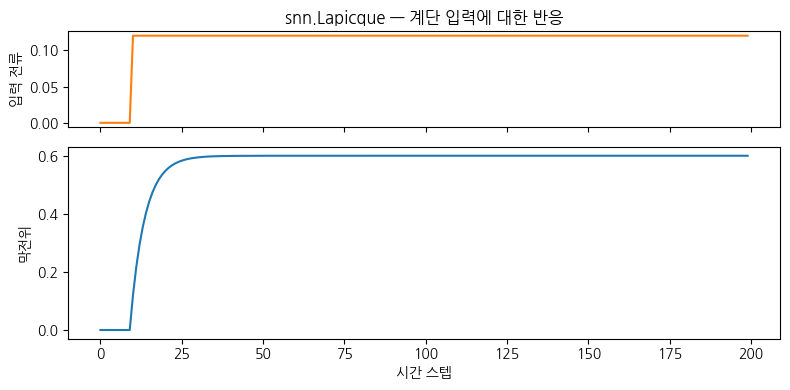

In [3]:
lif = snn.Lapicque(R=5.0, C=1e-3, time_step=1e-3)   # RC 기반 LIF 뉴런

num_steps = 200
cur_in = torch.cat(
    [torch.zeros(10, 1), 
     torch.ones(190, 1) * 0.12]
)  # 10스텝 뒤 입력 ON
mem = torch.zeros(1)        # 초기 막전위
mem_rec = []
spk_rec = []

# 시간 스텝마다 (스파이크, 막전위) 갱신
for step in range(num_steps):
    spk, mem = lif(cur_in[step], mem)
    mem_rec.append(mem)
    spk_rec.append(spk)

mem_rec = torch.stack(mem_rec)
spk_rec = torch.stack(spk_rec)

fig, (a0, a1) = plt.subplots(
    2, 1, 
    figsize=(8, 4), 
    sharex=True,
    gridspec_kw={'height_ratios': [1, 2]}
)
a0.plot(cur_in.squeeze().numpy(), color='tab:orange'); a0.set_ylabel('입력 전류')
a0.set_title('snn.Lapicque — 계단 입력에 대한 반응')
a1.plot(mem_rec.squeeze().numpy(), color='tab:blue'); a1.set_ylabel('막전위')
a1.set_xlabel('시간 스텝')
plt.tight_layout()
plt.show()

## 4. 감쇠율 `beta` 비교 — `snn.Leaky`

실무에서 더 자주 쓰는 `snn.Leaky`는 누설을 감쇠율 `beta` 하나로 표현한다. `beta`가 클수록 과거 입력을 오래 기억해 막전위가 더 높이 쌓이고 발화가 잦아진다. 세 가지 `beta`를 같은 입력으로 비교한다.

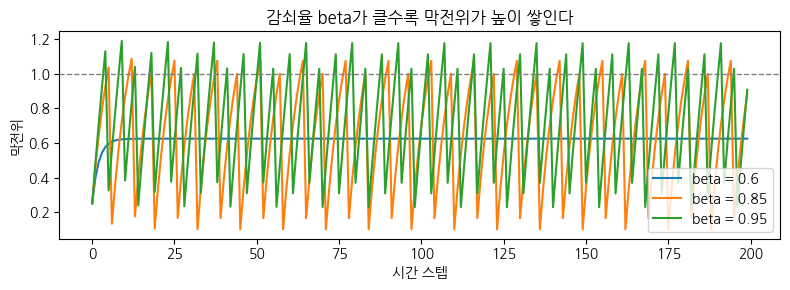

In [4]:
num_steps = 200
cur_in = torch.ones(num_steps, 1) * 0.25      # 일정한 입력 전류

def run_leaky(beta):
    lif = snn.Leaky(beta=beta)
    mem = lif.init_leaky()
    mem_rec = []
    for step in range(num_steps):
        spk, mem = lif(cur_in[step], mem)
        mem_rec.append(mem)
    return torch.stack(mem_rec).squeeze().detach().numpy()

plt.figure(figsize=(8, 3))
for beta in [0.6, 0.85, 0.95]:
    plt.plot(run_leaky(beta), label=f'beta = {beta}')
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1)   # 임계값
plt.xlabel('시간 스텝')
plt.ylabel('막전위')
plt.title('감쇠율 beta가 클수록 막전위가 높이 쌓인다')
plt.legend()
plt.tight_layout()
plt.show()

## 5. 리셋 방식 비교 — 빼기 vs 영점

발화 후 막전위를 되돌리는 방식은 두 가지다. `reset_mechanism='subtract'`는 임계값만큼만 빼서 초과분을 남기고, `'zero'`는 0으로 완전히 초기화한다. 같은 입력으로 두 방식을 비교한다.

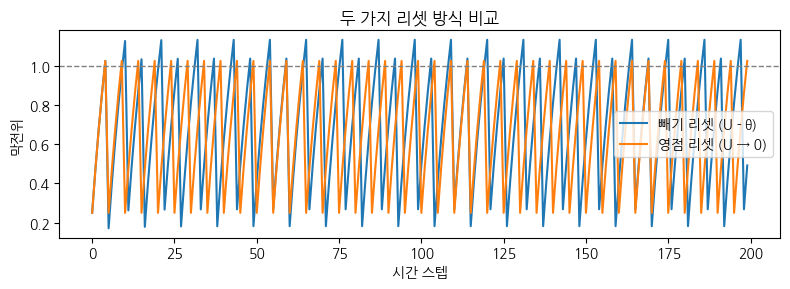

In [5]:
num_steps = 200
cur_in = torch.ones(num_steps, 1) * 0.25

def run_reset(mode):
    lif = snn.Leaky(beta=0.9, reset_mechanism=mode)
    mem = lif.init_leaky()
    mem_rec = []
    for step in range(num_steps):
        spk, mem = lif(cur_in[step], mem)
        mem_rec.append(mem)
    return torch.stack(mem_rec).squeeze().detach().numpy()

plt.figure(figsize=(8, 3))
plt.plot(run_reset('subtract'), label='빼기 리셋 (U - θ)', color='tab:blue')
plt.plot(run_reset('zero'), label='영점 리셋 (U → 0)', color='tab:orange')
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('시간 스텝')
plt.ylabel('막전위')
plt.title('두 가지 리셋 방식 비교')
plt.legend()
plt.tight_layout()
plt.show()

## 정리

- 막전위는 RC 누설 적분식을 따르며 `tau = R*C`가 반응 속도를 정한다.
- `snn.Lapicque`는 RC 파라미터를, `snn.Leaky`는 감쇠율 `beta`를 직접 받는다.
- `beta`가 클수록 기억이 길고 발화가 잦으며, 리셋 방식은 `reset_mechanism`으로 고른다.

다음 5장에서는 이 뉴런들을 층으로 쌓아 피드포워드 SNN을 구성한다.